In [5]:
# Importiamo le librerie necessarie
import pandas as pd
import numpy as np

In [14]:
# 1. Caricamento del dataset e identificazione delle variabili
print("--- 1. CARICAMENTO DATI ---")
try:
    df = pd.read_csv('ecommerce_customer_churn_dataset.csv')
    print("Dataset caricato con successo!")
except FileNotFoundError:
    print("Errore: Il file non si trova nella stessa cartella del notebook.")

print("\n--- INFORMAZIONI SULLE VARIABILI ---")
df.info()

# 2. Controllo valori mancanti e duplicati
print("\n--- 2. SALUTE DEL DATASET ---")
missing_values = df.isnull().sum()
print("Valori mancanti per colonna:\n", missing_values[missing_values > 0])
duplicates = df.duplicated().sum()
print(f"\nNumero di righe duplicate: {duplicates}")

# Tabella riassuntiva (Statistiche descrittive di base)
print("\n--- 3. TABELLA RIASSUNTIVA (Variabili Numeriche) ---")
display(df.describe())

# --- 4. PULIZIA DEI DATI (Imputazione Valori Mancanti) ---
print("\n--- INIZIO IMPUTAZIONE VALORI MANCANTI ---")

# Creiamo una copia per non modificare il file originale
df_clean = df.copy()

# STRATEGIA 1: Riempimento con la Mediana
# Usiamo la mediana per età e metriche di comportamento generico perché meno sensibile agli outlier
cols_to_median = [
    'Age', 'Session_Duration_Avg', 'Pages_Per_Session', 
    'Days_Since_Last_Purchase', 'Discount_Usage_Rate', 
    'Returns_Rate', 'Email_Open_Rate', 'Credit_Balance'
]

for col in cols_to_median:
    if col in df_clean.columns:
        median_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_val)

# STRATEGIA 2: Riempimento con Zero
# Per metriche di interazione opzionali, se mancano assumiamo che l'azione non sia avvenuta
cols_to_zero = [
    'Wishlist_Items', 'Customer_Service_Calls', 
    'Product_Reviews_Written', 'Social_Media_Engagement_Score', 
    'Mobile_App_Usage', 'Payment_Method_Diversity'
]

for col in cols_to_zero:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(0)

# Controllo finale della pulizia
missing_after = df_clean.isnull().sum().sum()
print(f"Valori mancanti totali dopo l'imputazione: {missing_after}")

if missing_after == 0:
    print("Ottimo lavoro! Il dataset ora è pulito e pronto per l'analisi.")
    
# Mostriamo le prime righe del dataset pulito per sicurezza
display(df_clean.head())

--- 1. CARICAMENTO DATI ---
Dataset caricato con successo!

--- INFORMAZIONI SULLE VARIABILI ---
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47505 non-null  float64
 1   Gender                         50000 non-null  str    
 2   Country                        50000 non-null  str    
 3   City                           50000 non-null  str    
 4   Membership_Years               50000 non-null  float64
 5   Login_Frequency                50000 non-null  float64
 6   Session_Duration_Avg           46601 non-null  float64
 7   Pages_Per_Session              47000 non-null  float64
 8   Cart_Abandonment_Rate          50000 non-null  float64
 9   Wishlist_Items                 46000 non-null  float64
 10  Total_Purchases                50000 non-null  float64
 11  Average_Order_Value 

,Age,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,...,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned
count,47505.000000,50000.000000,50000.000000,46601.000000,47000.000000,50000.000000,46000.000000,50000.000000,50000.000000,47000.000000,...,45509.000000,47472.000000,49832.000000,46500.000000,44000.000000,45000.000000,47500.000000,50000.000000,44500.000000,50000.000000
mean,37.802968,2.984009,11.624660,27.660754,8.737811,57.079973,4.298391,13.111576,123.117330,29.792872,...,6.680913,20.937980,5.681831,2.853312,29.364466,19.371607,2.353874,1440.626292,1966.233258,0.289000
std,11.834668,2.059105,7.810657,10.871013,3.778220,16.282723,3.189754,7.017312,175.569714,29.695062,...,6.143027,14.252561,2.676052,2.328948,20.574021,9.419252,1.110012,907.249443,1225.072166,0.453302
min,5.000000,0.100000,0.000000,1.000000,1.000000,0.000000,0.000000,-13.000000,26.380000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,29.000000,1.400000,6.000000,19.700000,6.000000,46.400000,2.000000,8.000000,87.050000,9.000000,...,2.900000,9.900000,4.000000,1.000000,13.200000,12.500000,2.000000,789.817500,1049.000000,0.000000
50%,38.000000,2.500000,11.000000,26.800000,8.400000,58.100000,4.000000,12.000000,112.970000,21.000000,...,5.400000,19.700000,5.000000,2.000000,27.600000,18.600000,2.000000,1243.415000,1896.000000,0.000000
75%,46.000000,4.000000,17.000000,34.700000,11.200000,68.700000,6.000000,17.000000,144.440000,41.000000,...,9.100000,30.400000,7.000000,4.000000,43.100000,25.500000,3.000000,1874.000000,2791.000000,1.000000
max,200.000000,10.000000,46.000000,75.600000,24.100000,143.743350,28.000000,128.700000,9666.379178,287.000000,...,99.615734,91.700000,21.000000,21.000000,100.000000,61.900000,5.000000,8987.240000,7197.000000,1.000000



--- INIZIO IMPUTAZIONE VALORI MANCANTI ---
Valori mancanti totali dopo l'imputazione: 0
Ottimo lavoro! Il dataset ora è pulito e pronto per l'analisi.


,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,0.0,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,0.0,8.8,0.0,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,8.4,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


--- FASE 2: ANALISI DESCRITTIVA E VISUALIZZAZIONE ---

1. STATISTICHE DESCRITTIVE (Media, Mediana, Std Dev, Skewness):


,mean,median,std,skew
Age,37.81,38.00,11.54,0.97
Membership_Years,2.98,2.50,2.06,1.14
Login_Frequency,11.62,11.00,7.81,0.51
Session_Duration_Avg,27.60,26.80,10.50,0.43
Pages_Per_Session,8.72,8.40,3.66,0.42
Cart_Abandonment_Rate,57.08,58.10,16.28,-0.26
Wishlist_Items,3.95,3.00,3.27,0.94
Total_Purchases,13.11,12.00,7.02,2.69
Average_Order_Value,123.12,112.97,175.57,42.36
Days_Since_Last_Purchase,29.27,21.00,28.87,2.09



2. TOP 5 CORRELAZIONI PIÙ SIGNIFICATIVE:


,,Correlazione
Pages_Per_Session,Session_Duration_Avg,0.714086
Session_Duration_Avg,Login_Frequency,0.685319
Cart_Abandonment_Rate,Session_Duration_Avg,-0.677323
Login_Frequency,Pages_Per_Session,0.654605
Pages_Per_Session,Cart_Abandonment_Rate,-0.648117



3. DISTRIBUZIONE DEL CHURN:


,Clienti,Percentuale (%)
Attivi (0),35550,71.1
Abbandonati (1),14450,28.9



4. VISUALIZZAZIONI GRAFICHE:


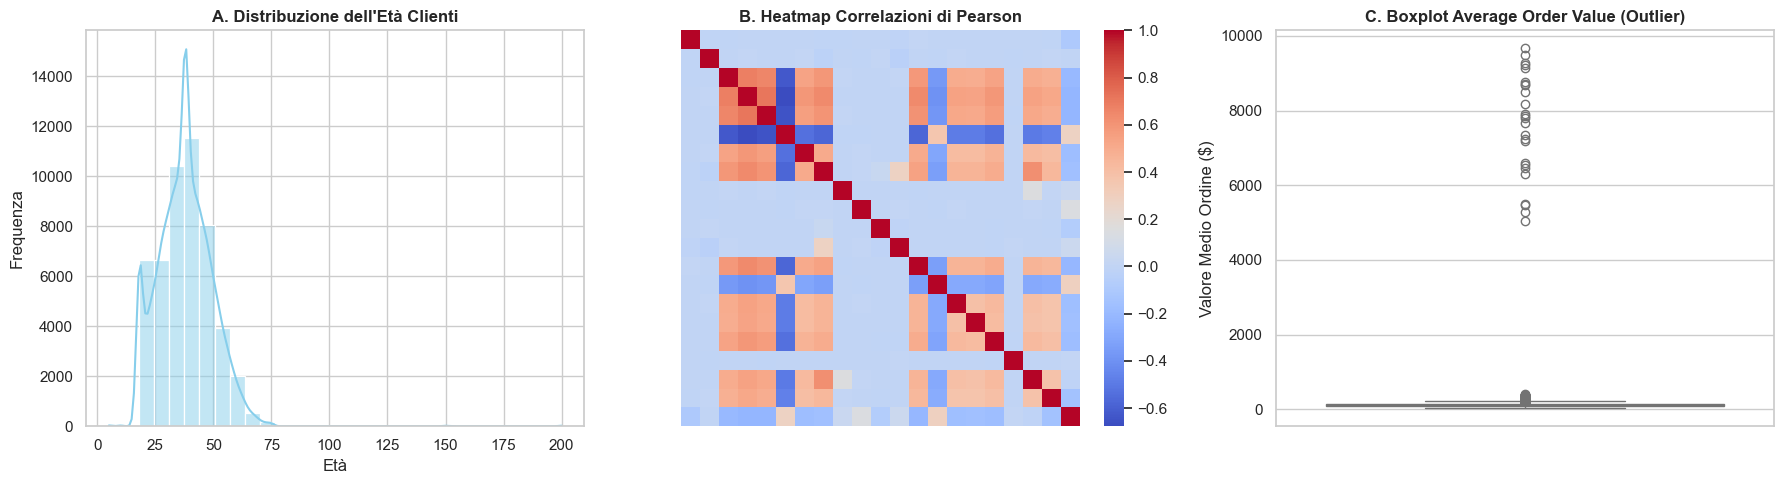

In [15]:
# Importiamo le librerie grafiche
import matplotlib.pyplot as plt
import seaborn as sns

print("--- FASE 2: ANALISI DESCRITTIVA E VISUALIZZAZIONE ---\n")

# 1. Statistiche Descrittive Avanzate (Solo su colonne numeriche)
print("1. STATISTICHE DESCRITTIVE (Media, Mediana, Std Dev, Skewness):")
numeric_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns
# Escludiamo ID o target binari dalle statistiche di base per pulizia
stats_cols = [col for col in numeric_cols if col not in ['Churned']]

desc_stats = df_clean[stats_cols].agg(['mean', 'median', 'std', 'skew']).T
display(desc_stats.round(2))

# 2. Le 5 correlazioni più significative (Pearson)
print("\n2. TOP 5 CORRELAZIONI PIÙ SIGNIFICATIVE:")
# Calcoliamo la matrice di correlazione
corr_matrix = df_clean[numeric_cols].corr(method='pearson')

# Estraiamo le coppie uniche e le ordiniamo per valore assoluto
corr_pairs = corr_matrix.unstack().sort_values(key=abs, ascending=False)
# Rimuoviamo le correlazioni perfette (variabile con se stessa = 1.0) e i duplicati speculari
corr_pairs = corr_pairs[corr_pairs != 1.0].drop_duplicates()
display(corr_pairs.head(5).to_frame(name='Correlazione'))

# 3. Distribuzione del Target (Churn)
print("\n3. DISTRIBUZIONE DEL CHURN:")
churn_counts = df_clean['Churned'].value_counts()
churn_rates = df_clean['Churned'].value_counts(normalize=True) * 100

churn_summary = pd.DataFrame({
    'Clienti': churn_counts,
    'Percentuale (%)': churn_rates.round(2)
})
churn_summary.index = ['Attivi (0)', 'Abbandonati (1)'] if 0 in churn_summary.index else churn_summary.index
display(churn_summary)

# 4. Visualizzazioni (3 Plot richiesti)
print("\n4. VISUALIZZAZIONI GRAFICHE:")
# Impostiamo lo stile grafico professionale
sns.set_theme(style="whitegrid", palette="muted")

# Creiamo una figura con 3 sotto-grafici affiancati
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A: Istogramma dell'Età
sns.histplot(df_clean['Age'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('A. Distribuzione dell\'Età Clienti', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Età')
axes[0].set_ylabel('Frequenza')

# Plot B: Heatmap delle Correlazioni
# Per leggibilità nascondiamo le etichette, mostriamo la mappa termica generale
sns.heatmap(corr_matrix, cmap='coolwarm', ax=axes[1], cbar=True, xticklabels=False, yticklabels=False)
axes[1].set_title('B. Heatmap Correlazioni di Pearson', fontsize=12, fontweight='bold')

# Plot C: Boxplot per gli Outlier (Spesa Media)
sns.boxplot(y=df_clean['Average_Order_Value'], ax=axes[2], color='lightgreen')
axes[2].set_title('C. Boxplot Average Order Value (Outlier)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Valore Medio Ordine ($)')

plt.tight_layout()
plt.show()

--- INIZIO SEGMENTAZIONE CLIENTI (RFM) ---

Calcolo del numero ottimale di cluster (Elbow Method)...


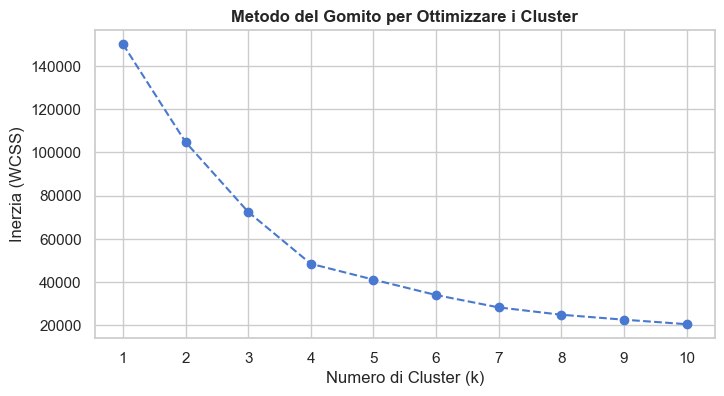


-> Basandoci sul grafico e sulla logica di business, procediamo con 4 cluster.

3. PROFILING DEI SEGMENTI:


,Recency Media (Giorni),Frequency Media (Acquisti),Monetary Medio ($),Num_Clienti
Segmento,,,,
0,84.76,12.62,119.31,7241
1,19.48,9.16,119.65,27267
2,29.80,14.40,7593.42,25
3,20.54,20.31,118.93,15467



4. VISUALIZZAZIONE DEI CLUSTER (Scatter Plot 3D):


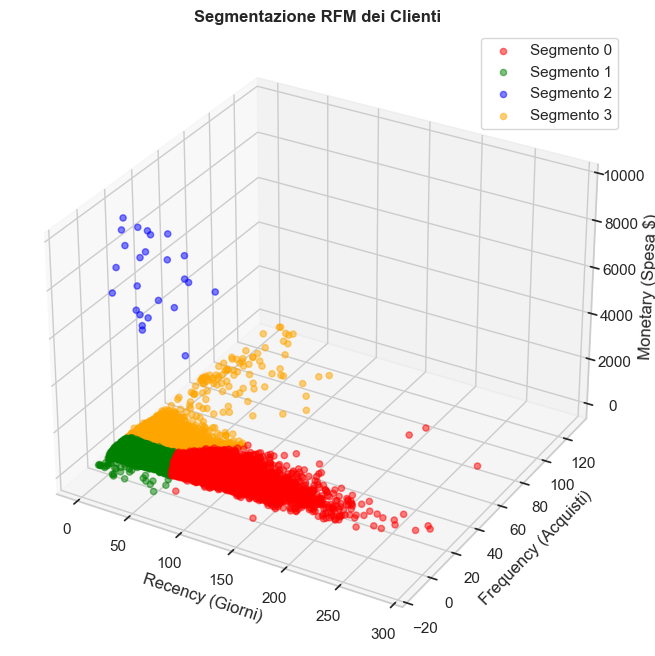

In [17]:
# --- FASE 3: CUSTOMER SEGMENTATION (RFM & K-Means) ---
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

print("--- INIZIO SEGMENTAZIONE CLIENTI (RFM) ---\n")

# 1. Preparazione dei dati RFM
# Selezioniamo le tre colonne chiave per l'RFM
rfm_cols = ['Days_Since_Last_Purchase', 'Total_Purchases', 'Average_Order_Value']
rfm_data = df_clean[rfm_cols].copy()

# Rinominare per chiarezza
rfm_data.columns = ['Recency', 'Frequency', 'Monetary']

# Standardizzazione dei dati (fondamentale per il K-Means)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_data)

# 2. Determinare il numero ottimale di cluster (Metodo del Gomito)
print("Calcolo del numero ottimale di cluster (Elbow Method)...")
inertia = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

# Tracciamo il grafico del Metodo del Gomito
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.title('Metodo del Gomito per Ottimizzare i Cluster', fontsize=12, fontweight='bold')
plt.xlabel('Numero di Cluster (k)')
plt.ylabel('Inerzia (WCSS)')
plt.xticks(K_range)
plt.grid(True)
plt.show()

# Business Logic: Dal grafico, il "gomito" (il punto in cui la curva inizia ad appiattirsi)
# si trova solitamente intorno a k=3 o k=4. Scegliamo k=4 per una segmentazione marketing efficace:
# Es: "Clienti VIP", "Clienti Fedeli", "Nuovi/Occasionali", "A Rischio Abbandono".
optimal_k = 4
print(f"\n-> Basandoci sul grafico e sulla logica di business, procediamo con {optimal_k} cluster.\n")

# Esecuzione del K-Means finale
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_clean['Segmento'] = kmeans_final.fit_predict(rfm_scaled)

# 3. Profiling: Creiamo la tabella descrittiva dei segmenti
print("3. PROFILING DEI SEGMENTI:")
segment_profile = df_clean.groupby('Segmento')[['Days_Since_Last_Purchase', 'Total_Purchases', 'Average_Order_Value']].mean().round(2)
segment_profile.columns = ['Recency Media (Giorni)', 'Frequency Media (Acquisti)', 'Monetary Medio ($)']
segment_profile['Num_Clienti'] = df_clean['Segmento'].value_counts()
display(segment_profile)

# 4. Visualizzazione Grafica dei Cluster (Scatter Plot 3D)
print("\n4. VISUALIZZAZIONE DEI CLUSTER (Scatter Plot 3D):")
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Assegniamo colori diversi ai cluster
colors = ['red', 'green', 'blue', 'orange']
for i in range(optimal_k):
    cluster_data = df_clean[df_clean['Segmento'] == i]
    ax.scatter(cluster_data['Days_Since_Last_Purchase'], 
               cluster_data['Total_Purchases'], 
               cluster_data['Average_Order_Value'], 
               c=colors[i], label=f'Segmento {i}', alpha=0.5, s=20)

ax.set_xlabel('Recency (Giorni)')
ax.set_ylabel('Frequency (Acquisti)')
ax.set_zlabel('Monetary (Spesa $)')
ax.set_title('Segmentazione RFM dei Clienti', fontweight='bold')
ax.legend()
plt.show()

# Fase 4: Executive Summary & Strategic Action Plan

## 1. Executive Summary (Insights per il CEO)
* **Elevato Rischio di Churn Silente:** Un segmento corposo di clienti presenta una *Recency* molto alta, indicando che una parte significativa della base utenti non effettua acquisti da mesi ed è a rischio abbandono definitivo.
* **Dipendenza dai "Whales" (Altospendenti):** Il fatturato è fortemente influenzato da un gruppo estremamente ristretto di clienti (Segmento VIP) che generano ordini con un *Average Order Value* eccezionalmente superiore alla media.
* **Potenziale Inespresso sui Nuovi Acquisiti:** Esiste un ampio bacino di clienti con acquisti recenti ma bassa frequenza e spesa minima. La mancata fidelizzazione in questa fase iniziale rappresenta una grande perdita di *Lifetime Value* (LTV).

---

## 2. Action Plan (Tattiche per Segmento RFM)

1. **Segmento Blu (VIP / High Rollers - Alta Spesa):**
   * *Tattica:* **White-Glove Service**. Assegnare un account manager dedicato o un servizio clienti prioritario, offrendo anteprime esclusive sui nuovi prodotti ad alto margine senza sconti, puntando sull'esclusività.
2. **Segmento Arancione (Fedeli / Frequent Buyers - Alta Frequenza):**
   * *Tattica:* **Subscription Model & Loyalty**. Introdurre un programma a punti o abbonamenti per le spedizioni gratuite (stile Amazon Prime) per blindare la loro abitudine d'acquisto e aumentare leggermente lo scontrino medio.
3. **Segmento Verde (Nuovi / Promettenti - Bassa Recency, Bassa Frequenza):**
   * *Tattica:* **Onboarding & Cross-sell Automations**. Attivare una sequenza email di benvenuto che offra un incentivo a tempo (es. -15%) sul *secondo* acquisto basato sui prodotti correlati al primo, per trasformarli rapidamente in acquirenti abituali.
4. **Segmento Rosso (Dormienti / At-Risk - Alta Recency):**
   * *Tattica:* **Aggressive Win-Back Campaign**. Lanciare campagne mirate di retargeting (Email + Social) con sconti forti (es. -30% o spedizione gratuita assoluta) mirati solo a chi non acquista da oltre 100 giorni.

---

## 3. KPIs (Metriche di Misurazione)
Per misurare l'impatto di queste iniziative nel prossimo trimestre, monitoreremo:
1. **Customer Retention Rate (CRR):** Per valutare l'efficacia delle campagne Win-Back sul cluster dei Dormienti.
2. **Average Order Value (AOV) del Segmento Fedele:** Per misurare il successo delle tattiche di up-selling sul cluster ad alta frequenza.
3. **Time Between Purchases (TBP):** Per capire se stiamo riuscendo ad accelerare il secondo acquisto nei Nuovi Clienti.